In [14]:
# Load curated metrics from PostgreSQL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.notebook_helpers import get_postgres_engine

engine, pg_conf = get_postgres_engine("../configs/database.yaml")

df = pd.read_sql_query("SELECT * FROM curated_device_metrics", engine)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Connected to PostgreSQL:", pg_conf["host"], pg_conf["db"])
print("rows:", len(df), "columns:", len(df.columns))
df.head()

Connected to PostgreSQL: localhost storage_analytics
rows: 30240 columns: 40


,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,merge_rate_total,merge_efficiency,await_ratio,svctm_await_ratio,queue_efficiency,write_amplification,iowait_pressure,hour_of_day,day_of_week,workload_pattern
0,dm-0,2026-03-31 04:08:48.788146+00:00,140.959655,93.619543,11.583757,11.157970,1.105820,1.716876,1.007422,28.140755,...,26.534528,0.101621,1.552581,0.272647,232.850888,0.664158,0.078511,4,1,balanced
1,dm-0,2026-03-31 04:14:05.186622+00:00,109.506332,151.268915,10.743113,8.750184,0.626107,0.697533,0.584874,13.622792,...,21.427501,0.075929,1.114080,0.627405,445.865765,1.381371,0.042323,4,1,balanced
2,dm-0,2026-03-31 04:18:56.680771+00:00,230.409045,128.590401,10.278032,6.651877,0.659138,0.854048,1.721116,15.926286,...,22.504196,0.058988,1.295704,0.499544,208.585287,0.558096,0.707887,4,1,balanced
3,dm-0,2026-03-31 04:24:12.273969+00:00,119.060467,110.859152,13.975260,9.628488,0.446518,0.593059,0.563965,1.101808,...,28.846208,0.111476,1.328186,0.767394,407.684039,0.931116,0.005333,4,1,balanced
4,dm-0,2026-03-31 04:28:57.613327+00:00,144.429396,109.510144,9.840768,10.967174,0.606786,1.229986,0.484494,22.938399,...,19.965266,0.072891,2.027051,0.504163,524.133581,0.758226,0.407328,4,1,balanced


In [15]:
df["device"].nunique()
df.shape
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2026-03-31 04:08:48.788146+0000', tz='UTC'),
 Timestamp('2026-04-07 22:09:23.052181+0000', tz='UTC'))

In [16]:
eda_cols = [
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "aqu_sz",
    "saturation_score",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
    "write_amplification",
]
df[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_iops,30240.0,415.638293,514.776042,10.174500,139.071182,260.112106,491.062118,7935.754329
avg_latency_ms,30240.0,47.268516,2701.878062,0.037558,0.403439,0.984769,1.949532,453008.805530
util_pct,30240.0,30.500694,24.195706,0.000000,12.786900,24.929521,42.478491,100.000000
aqu_sz,30240.0,0.889370,1.332070,0.018838,0.254949,0.499015,1.026958,43.141044
saturation_score,30240.0,40.075785,99.824605,0.000000,3.322041,11.876345,38.853136,3871.579221
merge_efficiency,30240.0,0.104625,0.112885,0.000013,0.036537,0.063140,0.102255,0.661635
queue_efficiency,30240.0,874.529040,994.620399,3.433468,278.897459,582.557389,1147.341094,30955.638747
iowait_pressure,30240.0,2.061067,5.570052,0.000000,0.062004,0.442680,1.600930,100.000000
svctm_await_ratio,30240.0,1.211171,17.674960,0.000027,0.318490,0.385296,0.485091,2622.607213
write_amplification,30240.0,1.020361,1.696119,0.043961,0.609470,0.829100,1.129574,194.692792


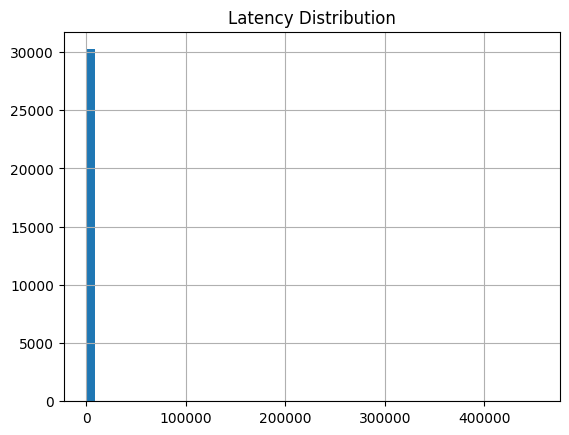

In [17]:
df["avg_latency_ms"].hist(bins=50)
plt.title("Latency Distribution")
plt.show()

In [18]:
quantiles = df[[
    "avg_latency_ms",
    "total_iops",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
]].quantile([0.5, 0.9, 0.95, 0.99])
quantiles

,avg_latency_ms,total_iops,merge_efficiency,queue_efficiency,iowait_pressure
0.50,0.984769,260.112106,0.063140,582.557389,0.442680
0.90,16.485695,888.057326,0.314993,1860.018054,4.556567
0.95,62.811403,1289.372209,0.377637,2744.032148,8.804238
0.99,491.088699,2682.576096,0.467552,4377.799158,31.388611


In [19]:
df.groupby("device")[[
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
    "write_amplification",
]].mean().round(4).sort_values("avg_latency_ms", ascending=False)

,total_iops,avg_latency_ms,util_pct,merge_efficiency,queue_efficiency,iowait_pressure,svctm_await_ratio,write_amplification
device,,,,,,,,
sdb,161.1459,231.9392,44.0131,0.3014,182.9576,6.4568,4.3887,1.8719
sda,253.0436,2.2035,29.5197,0.0733,550.2268,1.2734,0.4996,0.9906
dm-0,370.8492,1.1461,24.9059,0.0804,503.1481,0.8550,0.4108,0.9270
nvme0n1,318.6463,0.5849,18.1848,0.0360,1644.7811,0.4806,0.4076,0.5203
nvme1n1,974.5064,0.4689,35.8800,0.0321,1491.5316,1.2395,0.3491,0.7920


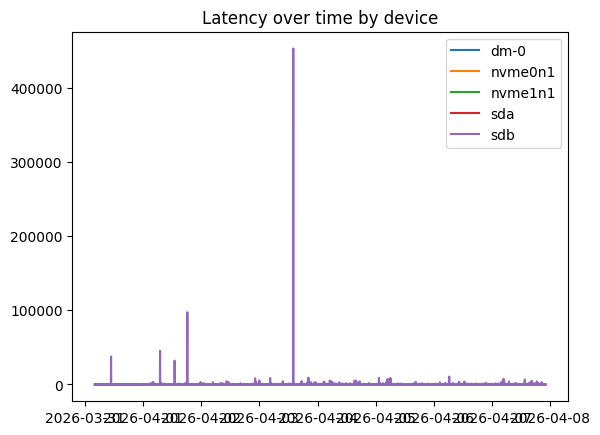

In [20]:
for device in df["device"].unique():
    subset = df[df["device"] == device]
    plt.plot(subset["timestamp"], subset["avg_latency_ms"], label=device)

plt.legend()
plt.title("Latency over time by device")
plt.show()

In [21]:
corr_cols = [
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "aqu_sz",
    "saturation_score",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "svctm_await_ratio",
]
df[corr_cols].corr()

,total_iops,avg_latency_ms,util_pct,aqu_sz,saturation_score,merge_efficiency,queue_efficiency,iowait_pressure,svctm_await_ratio
total_iops,1.000000,0.002322,0.507451,0.130223,0.190272,-0.337276,0.491167,0.180677,-0.025442
avg_latency_ms,0.002322,1.000000,0.027963,0.024878,0.033260,0.025099,-0.010923,0.095533,-0.001112
util_pct,0.507451,0.027963,1.000000,0.401789,0.523507,0.099881,0.068482,0.646335,0.015241
aqu_sz,0.130223,0.024878,0.401789,1.000000,0.911807,0.301327,-0.273343,0.384459,0.026146
saturation_score,0.190272,0.033260,0.523507,0.911807,1.000000,0.203752,-0.161656,0.537375,0.021653
merge_efficiency,-0.337276,0.025099,0.099881,0.301327,0.203752,1.000000,-0.447477,0.164259,0.074476
queue_efficiency,0.491167,-0.010923,0.068482,-0.273343,-0.161656,-0.447477,1.000000,-0.078152,-0.032506
iowait_pressure,0.180677,0.095533,0.646335,0.384459,0.537375,0.164259,-0.078152,1.000000,0.022815
svctm_await_ratio,-0.025442,-0.001112,0.015241,0.026146,0.021653,0.074476,-0.032506,0.022815,1.000000


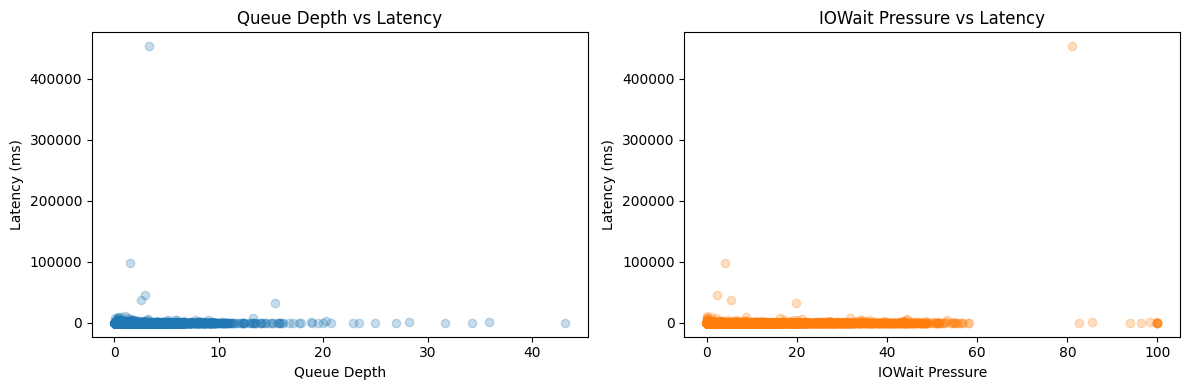

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["aqu_sz"], df["avg_latency_ms"], alpha=0.25)
axes[0].set_xlabel("Queue Depth")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Queue Depth vs Latency")

axes[1].scatter(df["iowait_pressure"], df["avg_latency_ms"], alpha=0.25, color="tab:orange")
axes[1].set_xlabel("IOWait Pressure")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("IOWait Pressure vs Latency")

plt.tight_layout()
plt.show()

In [23]:
df["read_ratio"].describe()
df["write_ratio"].describe()

count    30240.000000
mean         0.461529
std          0.120597
min          0.042110
25%          0.378678
50%          0.453283
75%          0.530458
max          1.000000
Name: write_ratio, dtype: float64

In [24]:
df.groupby("hour_of_day")[[
    "total_iops",
    "avg_latency_ms",
    "iowait_pressure",
    "merge_efficiency",
    "queue_efficiency",
]].mean().round(3)

,total_iops,avg_latency_ms,iowait_pressure,merge_efficiency,queue_efficiency
hour_of_day,,,,,
0,203.800,16.223,0.756,0.105,863.968
1,211.181,25.346,0.581,0.106,874.251
2,216.241,22.134,0.583,0.106,838.266
3,232.454,21.379,0.765,0.104,869.744
4,241.378,53.416,1.111,0.106,842.676
5,289.974,31.216,1.172,0.104,963.293
6,320.515,39.425,1.245,0.105,903.440
7,372.627,55.930,1.474,0.105,873.952
8,431.510,17.309,2.079,0.105,871.661


In [25]:
threshold = df["avg_latency_ms"].quantile(0.99)
high_latency = df[df["avg_latency_ms"] > threshold]
high_latency[[
    "device",
    "timestamp",
    "avg_latency_ms",
    "aqu_sz",
    "util_pct",
    "merge_efficiency",
    "queue_efficiency",
    "iowait_pressure",
    "workload_pattern",
]].head(20)

,device,timestamp,avg_latency_ms,aqu_sz,util_pct,merge_efficiency,queue_efficiency,iowait_pressure,workload_pattern
8113,sdb,2026-03-31 08:13:39.045357+00:00,584.259732,0.683969,34.268376,0.299069,137.235023,1.582604,latency_sensitive
8144,sdb,2026-03-31 10:49:09.985928+00:00,37844.649680,2.521127,47.157055,0.336629,85.254732,5.414408,latency_sensitive
8182,sdb,2026-03-31 13:59:26.450201+00:00,649.815126,18.806819,47.865291,0.345772,9.376269,3.901268,latency_sensitive
8212,sdb,2026-03-31 16:29:22.531502+00:00,778.443895,8.168553,61.723340,0.300825,22.134252,8.619631,latency_sensitive
8300,sdb,2026-03-31 23:49:12.296685+00:00,932.017360,0.496723,10.690131,0.405436,127.105903,0.780640,latency_sensitive
8353,sdb,2026-04-01 04:13:38.111807+00:00,3496.325563,1.299524,31.967113,0.259761,68.397904,2.732283,latency_sensitive
8361,sdb,2026-04-01 04:54:19.664532+00:00,812.178418,1.022644,28.633460,0.330749,82.618300,1.203219,latency_sensitive
8383,sdb,2026-04-01 06:44:17.477468+00:00,893.031464,0.504512,36.124131,0.370964,436.302571,3.181397,latency_sensitive
8392,sdb,2026-04-01 07:29:27.178993+00:00,1071.665687,0.460110,47.867641,0.292494,867.680849,8.354691,latency_sensitive
8553,sdb,2026-04-01 20:53:58.308450+00:00,626.519801,0.679621,46.755501,0.360075,153.989680,1.684845,latency_sensitive


In [26]:
df.sort_values("saturation_score", ascending=False).head(10)

,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,merge_rate_total,merge_efficiency,await_ratio,svctm_await_ratio,queue_efficiency,write_amplification,iowait_pressure,hour_of_day,day_of_week,workload_pattern
28411,sdb,2026-04-01 13:26:58.378802+00:00,102.549023,123.668431,12.260614,9.133318,4.155520,10.179537,43.141044,89.742364,...,112.382917,0.331904,2.449642,0.557883,5.243671,1.205945,31.459683,13,2,latency_sensitive
28410,sdb,2026-04-01 13:21:50.110199+00:00,62.504691,127.857360,7.952395,8.585161,2316.553156,11.711846,35.823917,94.642991,...,105.152873,0.355829,0.005056,0.001971,5.313826,2.045564,28.889611,13,2,latency_sensitive
18980,sdb,2026-04-03 19:29:35.020165+00:00,64.323945,53.331341,5.476114,3.742964,136.756812,3.056501,34.267181,92.758398,...,40.890671,0.257911,0.022350,0.118969,3.433468,0.829106,31.959829,19,4,latency_sensitive
18952,sdb,2026-04-03 17:08:51.703783+00:00,140.026921,165.014790,4.088434,9.219950,3830.444251,24.696549,28.243927,100.000000,...,67.419014,0.181010,0.006447,0.003708,10.800258,1.178450,24.140858,17,4,latency_sensitive
9049,sdb,2026-04-03 14:14:09.479565+00:00,89.737369,166.947613,10.727815,6.937428,16.681900,5.304456,27.007887,82.440659,...,63.250194,0.197697,0.317977,0.785058,9.504075,1.860402,8.674113,14,4,latency_sensitive
28409,sdb,2026-04-01 13:17:05.560570+00:00,59.071126,125.472322,7.943137,7.839478,3.598182,11.149232,24.950468,88.212151,...,113.015491,0.379809,3.098573,0.412060,7.396392,2.124089,30.311550,13,2,latency_sensitive
19785,sdb,2026-04-06 14:34:20.884141+00:00,203.220248,312.010287,10.576772,11.713106,8.155780,36.761704,20.727447,100.000000,...,81.322147,0.136320,4.507442,0.378447,24.857405,1.535331,48.536884,14,0,latency_sensitive
333,dm-0,2026-04-01 07:54:10.512457+00:00,165.201487,145.531377,14.488316,9.211358,4.679283,11.050446,19.503819,96.081722,...,27.279769,0.080706,2.361568,0.202720,15.931898,0.880933,25.275417,7,2,latency_sensitive
28407,sdb,2026-04-01 13:07:00.082915+00:00,89.753755,102.085932,5.058673,8.799901,17.476126,4465.647486,20.309345,91.308859,...,81.633854,0.298507,255.528449,0.007329,9.445883,1.137400,32.808186,13,2,latency_sensitive
9858,sdb,2026-04-06 09:39:07.335304+00:00,47.382720,112.495341,2.964323,7.690740,2.254830,43.153369,31.622267,56.410115,...,55.902643,0.259072,19.138194,0.050453,5.055870,2.374185,4.672693,9,0,latency_sensitive
